In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("wbes_sintetico.csv")

vars_bayes = [
    "successful",
    "training",
    "access_finance",
    "competition_level",
    "exporter"
]

bayes_df = df[vars_bayes].dropna().copy()
bayes_df.head()

,successful,training,access_finance,competition_level,exporter
0,1,1.0,1.0,Media,0
1,0,0.0,0.0,Baja,0
2,0,0.0,0.0,Baja,1
3,1,1.0,0.0,Baja,1
4,1,0.0,0.0,Baja,0


In [21]:
for c in ["successful", "training", "access_finance", "exporter"]:
    bayes_df[c] = pd.to_numeric(bayes_df[c], errors="coerce").astype(int)

bayes_df["competition_level"] = bayes_df["competition_level"].astype(str)

bayes_df.dtypes

successful            int64
training              int64
access_finance        int64
competition_level    object
exporter              int64
dtype: object

In [23]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

In [24]:
model = DiscreteBayesianNetwork([
    ("training", "successful"),
    ("access_finance", "successful"),
    ("exporter", "successful"),
    ("competition_level", "successful"),
    ("access_finance", "exporter")
])

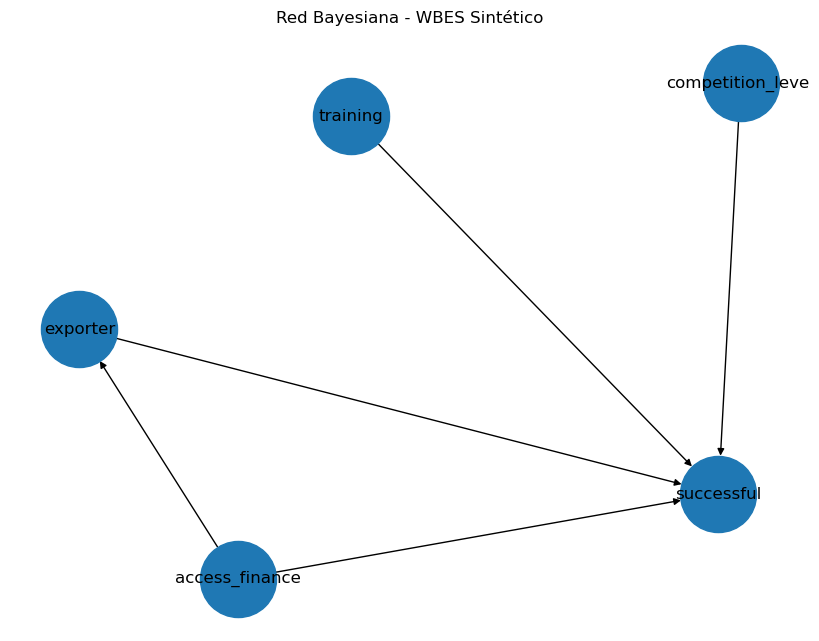

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_edges_from(list(model.edges()))

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=3000)
plt.title("Red Bayesiana - WBES Sintético")
plt.show()

In [26]:
model.fit(bayes_df, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'successful': 'N', 'training': 'N', 'access_finance': 'N', 'competition_level': 'C', 'exporter': 'N'}


In [32]:
inference = VariableElimination(model)

# Probabilidad base de éxito
p_base = inference.query(variables=["successful"])
print(p_base)

+---------------+-------------------+
| successful    |   phi(successful) |
+===============+===================+
| successful(0) |            0.5669 |
+---------------+-------------------+
| successful(1) |            0.4331 |
+---------------+-------------------+


In [33]:
p_fin = inference.query(
    variables=["successful"],
    evidence={"access_finance": 1}
)
print(p_fin)

+---------------+-------------------+
| successful    |   phi(successful) |
+===============+===================+
| successful(0) |            0.4849 |
+---------------+-------------------+
| successful(1) |            0.5151 |
+---------------+-------------------+


In [34]:
p_train = inference.query(
    variables=["successful"],
    evidence={"training": 1}
)
print(p_train)

+---------------+-------------------+
| successful    |   phi(successful) |
+===============+===================+
| successful(0) |            0.4951 |
+---------------+-------------------+
| successful(1) |            0.5049 |
+---------------+-------------------+


In [35]:
p_export_given_fin = inference.query(
    variables=["exporter"],
    evidence={"access_finance": 1}
)
print(p_export_given_fin)

+-------------+-----------------+
| exporter    |   phi(exporter) |
+=============+=================+
| exporter(0) |          0.8056 |
+-------------+-----------------+
| exporter(1) |          0.1944 |
+-------------+-----------------+


### Analiza y responde ¿Qué relaciones causales existen entre financiamiento, capacitación y éxito empresarial?

Los resultados muestran que tanto el financiamiento como la capacitación aumentan la probabilidad de éxito empresarial. La probabilidad base es 43.31%, pero sube a más del 50% cuando la empresa tiene acceso a financiamiento o capacitación. Esto indica que ambas variables influyen positivamente en el desempeño empresarial.

## • ¿Cuál modelo es más útil para un responsable de políticas públicas?

El modelo más útil para un responsable de políticas públicas es la red bayesiana. Aunque la regresión lineal y la logística permiten explicar y predecir el desempeño empresarial, la red bayesiana permite analizar cómo cambia la probabilidad de éxito cuando se interviene en variables como financiamiento o capacitación. Esto la hace más adecuada para evaluar posibles impactos de políticas antes de implementarlas.